# Lecture 12: Satellite Remote Sensing with Google Earth Engine
## F&W ECOL 458: Environmental Data Science

**Theme:** How can we use satellite imagery and cloud computing to monitor environmental conditions at scale?

**Learning Objectives:**
- Understand the physical principles of remote sensing
- Set up Google Earth Engine for academic use
- Master core GEE data types and operations
- Work with both raster (Image) and vector (Feature) data
- Apply reducers for spatial and temporal statistics
- Calculate and interpret vegetation indices

---

## 1. Introduction to Remote Sensing

### 1.1 What is Remote Sensing?

**Remote sensing** is the science of acquiring information about objects or areas from a distance, typically from aircraft or satellites. Unlike field measurements where you physically visit a location, remote sensing allows us to observe the entire planet repeatedly without leaving our desks.

**Why is remote sensing important for environmental science?**

1. **Scale**: We can observe entire continents, not just study plots
2. **Consistency**: Satellites collect data using the same sensors everywhere
3. **Temporal coverage**: Many satellites have collected data for decades
4. **Access**: We can study remote or dangerous areas (e.g., Arctic, active volcanoes)
5. **Cost**: Once satellites are launched, data collection is relatively inexpensive

### 1.2 The Electromagnetic Spectrum

All remote sensing is based on measuring **electromagnetic radiation** — the same physics that governs visible light, radio waves, and X-rays. The key insight is that different materials on Earth's surface interact differently with different wavelengths of light.

**How does it work?**

1. The **Sun** emits electromagnetic radiation across many wavelengths
2. This radiation travels to Earth and hits the surface
3. Different surfaces **absorb**, **reflect**, or **transmit** different wavelengths
4. Satellites measure the **reflected** radiation
5. By analyzing which wavelengths are reflected, we can identify surface properties

Think of it like this: a red apple appears red because it absorbs blue and green light but reflects red light back to your eyes. Satellites do the same thing, but they can "see" wavelengths beyond what human eyes can detect.

### 1.3 Spectral Bands and Their Applications

Satellites divide the electromagnetic spectrum into **bands** — specific wavelength ranges that reveal different information:

| Band | Wavelength | What It Measures | Why It Matters |
|------|------------|------------------|----------------|
| **Blue** | 0.45-0.52 µm | Scattered light | Water penetration, atmospheric haze |
| **Green** | 0.52-0.60 µm | Vegetation reflectance peak | Plant vigor, water turbidity |
| **Red** | 0.63-0.69 µm | Chlorophyll absorption | Vegetation health (low = healthy) |
| **NIR** | 0.76-0.90 µm | Leaf cell structure | Biomass, vegetation density |
| **SWIR** | 1.55-2.35 µm | Water in leaves/soil | Moisture stress, geology |
| **Thermal** | 10.4-12.5 µm | Emitted heat | Surface temperature |

**Key concept**: Healthy vegetation has a very distinctive "spectral signature" — it absorbs red light (for photosynthesis) but strongly reflects near-infrared light (due to leaf cell structure). This is why vegetation indices like NDVI work so well.

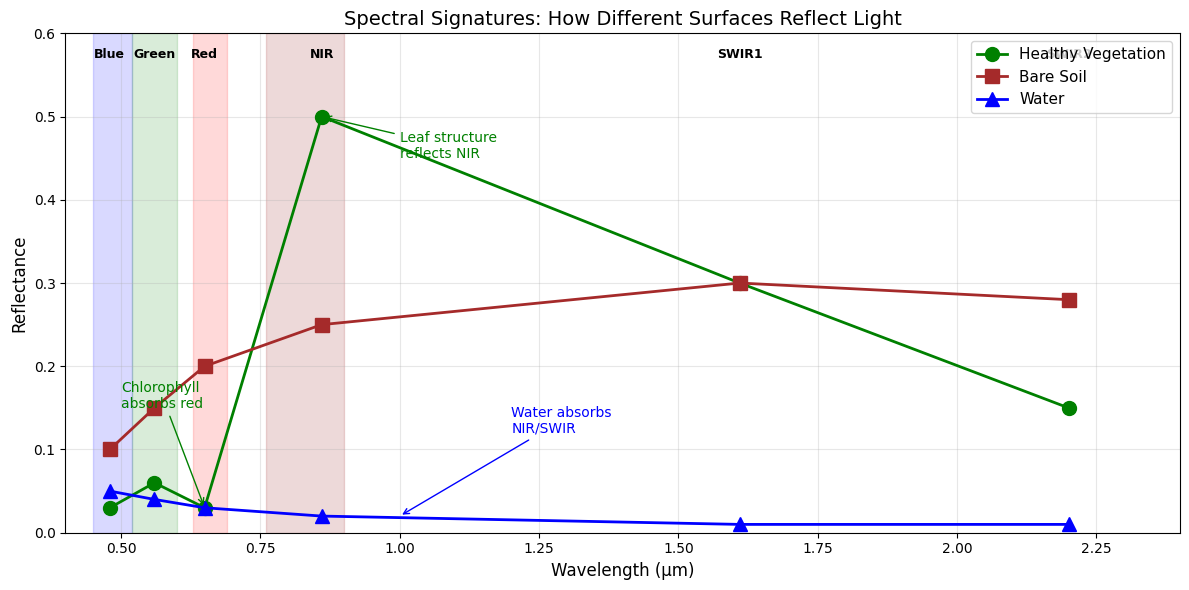

In [ ]:
# Let's visualize these spectral signatures
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 6))

# Wavelengths corresponding to Landsat bands (in micrometers)
wavelengths = [0.48, 0.56, 0.65, 0.86, 1.61, 2.20]
band_names = ['Blue', 'Green', 'Red', 'NIR', 'SWIR1', 'SWIR2']

# Typical reflectance values (proportion of light reflected, 0-1)
vegetation = [0.03, 0.06, 0.03, 0.50, 0.30, 0.15]  # Note: LOW red, HIGH NIR
soil = [0.10, 0.15, 0.20, 0.25, 0.30, 0.28]        # Gradually increasing
water = [0.05, 0.04, 0.03, 0.02, 0.01, 0.01]       # Low everywhere, especially NIR

ax.plot(wavelengths, vegetation, 'g-o', lw=2, ms=10, label='Healthy Vegetation')
ax.plot(wavelengths, soil, color='brown', ls='-', marker='s', lw=2, ms=10, label='Bare Soil')
ax.plot(wavelengths, water, 'b-^', lw=2, ms=10, label='Water')

# Shade the spectral regions
ax.axvspan(0.45, 0.52, alpha=0.15, color='blue', label='_')
ax.axvspan(0.52, 0.60, alpha=0.15, color='green', label='_')
ax.axvspan(0.63, 0.69, alpha=0.15, color='red', label='_')
ax.axvspan(0.76, 0.90, alpha=0.15, color='darkred', label='_')

# Add annotations
ax.annotate('Chlorophyll\nabsorbs red', xy=(0.65, 0.03), xytext=(0.5, 0.15),
            arrowprops=dict(arrowstyle='->', color='green'), fontsize=10, color='green')
ax.annotate('Leaf structure\nreflects NIR', xy=(0.86, 0.50), xytext=(1.0, 0.45),
            arrowprops=dict(arrowstyle='->', color='green'), fontsize=10, color='green')
ax.annotate('Water absorbs\nNIR/SWIR', xy=(1.0, 0.02), xytext=(1.2, 0.12),
            arrowprops=dict(arrowstyle='->', color='blue'), fontsize=10, color='blue')

ax.set_xlabel('Wavelength (µm)', fontsize=12)
ax.set_ylabel('Reflectance', fontsize=12)
ax.set_title('Spectral Signatures: How Different Surfaces Reflect Light', fontsize=14)
ax.legend(loc='upper right', fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim(0.4, 2.4)
ax.set_ylim(0, 0.6)

# Add band labels at top
for wl, name in zip(wavelengths, band_names):
    ax.annotate(name, (wl, 0.57), ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

### 1.4 Understanding the Vegetation Spectral Signature

The plot above reveals why satellite remote sensing is so powerful for vegetation monitoring:

**Why is vegetation LOW in red?**
- Chlorophyll molecules absorb red light (and blue light) to power photosynthesis
- Healthy plants with lots of chlorophyll absorb more red light
- Stressed or dying plants have less chlorophyll, so they reflect more red (appearing yellowish)

**Why is vegetation HIGH in NIR (near-infrared)?**
- The internal structure of leaves (spongy mesophyll cells) strongly scatters NIR light
- This has nothing to do with chlorophyll — it's purely physical structure
- More leaf layers = more NIR reflection = higher biomass

**Why does water absorb NIR?**
- Water molecules strongly absorb infrared radiation
- This is why water appears very dark in NIR imagery
- This property allows us to easily distinguish water from land

### 1.5 Common Satellite Sensors

Different satellites are designed for different purposes. The main tradeoffs are:

- **Spatial resolution**: How small an object can you see?
- **Temporal resolution**: How often does the satellite revisit the same location?
- **Spectral resolution**: How many bands, and how narrow are they?

| Satellite | Spatial Res | Revisit Time | Archive Since | Best For |
|-----------|-------------|--------------|---------------|----------|
| **Landsat 8/9** | 30 m | 16 days (8 with both) | 1972 | Long-term change, land cover |
| **Sentinel-2** | 10-20 m | 5 days | 2015 | Agriculture, vegetation detail |
| **MODIS** | 250-1000 m | Daily | 2000 | Phenology, fires, global patterns |
| **Sentinel-1** | 10 m | 6 days | 2014 | Radar (works through clouds) |

**The resolution tradeoff**: You generally can't have both high spatial AND high temporal resolution. A satellite that can see 1-meter details takes longer to cover the whole Earth than one that sees 500-meter pixels.

For this course, we'll primarily use **Landsat 8** (good balance of resolution and history) and **MODIS** (excellent for time series and phenology).

---
## 2. Getting Started with Google Earth Engine

### 2.1 What is Google Earth Engine?

**Google Earth Engine (GEE)** is a cloud-based platform that combines:

1. **A massive data catalog**: Petabytes of satellite imagery, climate data, terrain data, and more — all preprocessed and ready to use

2. **Cloud computing infrastructure**: Instead of downloading huge files to your laptop, you write code that runs on Google's servers. This means you can analyze the entire Landsat archive (40+ years, millions of images) in minutes.

3. **Free access for research and education**: Google provides this service at no cost for academic and non-commercial use

**Why use GEE instead of downloading data?**

| Traditional Approach | Google Earth Engine |
|---------------------|---------------------|
| Search for data on USGS website | Data already organized and indexed |
| Download GB/TB of files | Data stays on Google's servers |
| Store on your hard drive | No local storage needed |
| Process on your laptop (slow) | Process on Google's cloud (fast) |
| Install complex software | Just need a web browser or Python |

### 2.2 How to Register for Google Earth Engine

Before you can use GEE, you need to register for access and create a cloud project. Follow these steps carefully:

### **Important Note:**
Sometimes you may see different steps from what we describe below. You may need to explore the webpage and finally have a project id.

---

#### Step 1: Go to the Earth Engine Registration Page

Open your web browser and navigate to:

**https://code.earthengine.google.com/register**

---

#### Step 2: Sign in with Your Google Account

- Use the same email as the one you used for **colab**
- Click "Sign in" and enter your credentials

---

#### Step 3: Register as an Academic User

On the registration page:

1. **Select your account type**: Choose **"Unpaid usage"** → **"Academia & Research"**

2. **Fill in the registration form**:
   - **Institution**: University of Wisconsin-Madison
   - **Institution type**: University
   - **How will you use Earth Engine?**: Select "Education/Research"
   - **Describe your project**: Write a brief description, e.g.:
     > "Undergraduate coursework in environmental data science. Using satellite imagery to analyze land cover, vegetation phenology, and environmental change for class assignments."

3. **Accept the Terms of Service**: Read and check the box

4. **Click "Register"**

---

#### Step 4: Create a Google Cloud Project

After registration, you need to create a **Cloud Project**. This is how Google organizes and tracks usage.

1. Go to: **https://console.cloud.google.com/**

2. If prompted, agree to the Terms of Service

3. Click the project dropdown at the top of the page (it might say "Select a project")

4. Click **"New Project"** in the top right of the popup

5. **Configure your project**:
   - **Project name**: Choose something memorable, e.g., `ee-fw-ecol-458` or `ee-yourname-class`
   - **Organization**: Leave as "No organization" (or select your university if available)
   - **Location**: Leave as default

6. Click **"Create"**

7. **Save your Project ID**: After creation, note your **Project ID** (shown on the project dashboard). It looks like: `ee-fw-ecol-458` or might have numbers appended like `ee-fw-ecol-458-12345`. **You will need this ID in your code.**

---

#### Step 5: Enable the Earth Engine API

1. In the Google Cloud Console, make sure your new project is selected

2. Go to: **https://console.cloud.google.com/apis/library/earthengine.googleapis.com**

3. Click **"Enable"** to enable the Earth Engine API for your project

---

#### Step 6: Verify Your Setup

1. Go to the Earth Engine Code Editor: **https://code.earthengine.google.com/**

2. If you see the code editor interface with a map, you're ready!

3. If you get an error, wait 5-10 minutes for registration to propagate, then try again

---

#### Troubleshooting Common Issues

| Problem | Solution |
|---------|----------|
| "Access denied" error | Wait 10-15 minutes; registration can take time to process |
| Can't find project ID | Go to console.cloud.google.com, click project dropdown |
| "API not enabled" error | Make sure you completed Step 5 |
| "Quota exceeded" | Unlikely for class use; contact instructor if this happens |

---

### 2.3 Setting Up Python Access to Earth Engine

While GEE has a JavaScript code editor (code.earthengine.google.com), we'll use the **Python API** so we can integrate with pandas, matplotlib, and other tools you already know.

In [ ]:
# Install required packages (only need to run once)
!pip install geemap earthengine-api -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 19.1 MB/s eta 0:00:00


In [ ]:
# Import the Earth Engine library
import ee

# Import geemap for interactive mapping
import geemap

# Other libraries we'll use
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# AUTHENTICATION (Run this cell and follow the prompts)
#
# This will open a browser window asking you to sign in to Google
# and grant permission for this notebook to access Earth Engine.
#
# You only need to do this once per session.

ee.Authenticate()

In [ ]:
# INITIALIZATION
#
# Replace 'your-project-id' with the Project ID you created in Step 4 above.
# For example: 'ee-fw-ecol-458' or 'ee-jsmith-class'
#
# IMPORTANT: This must match exactly what's shown in your Google Cloud Console!

ee.Initialize(project='fwe458')  # <-- I have a project id 'fwe458' with my account. YOU SHOULD REPLACE THIS with yours

# Test that it worked
print("Earth Engine initialized successfully!")
print(f"Earth Engine version: {ee.__version__}")

Earth Engine initialized successfully!
Earth Engine version: 1.5.24


---
## 3. GEE Data Types and Basic Operations

### 3.1 Understanding Server-Side vs Client-Side

The most important concept to understand about GEE is the distinction between **server-side** and **client-side** objects:

| Client-Side (Your Computer) | Server-Side (Google's Cloud) |
|----------------------------|-----------------------------|
| Regular Python variables | `ee.` objects |
| `x = 5` | `x = ee.Number(5)` |
| Computed immediately | Computed only when requested |
| Limited by your RAM | Uses Google's infrastructure |

**Key insight**: When you write `ee.Image(...)` or `ee.Filter.lt(...)`, you're not doing the computation — you're building a **recipe** that tells Google what to compute. The actual computation happens on Google's servers only when you call `.getInfo()` or visualize the data.

This is called **lazy evaluation** and it's what makes GEE so powerful — Google can optimize the computation and only process the data you actually need.

### 3.2 Core Data Types

GEE has several fundamental data types:

| Type | Description | Real-World Example |
|------|-------------|-------------------|
| `ee.Image` | A raster image with bands | One Landsat scene |
| `ee.ImageCollection` | A stack/time series of images | All Landsat scenes from 2023 |
| `ee.Geometry` | A vector shape | A point, polygon, or rectangle |
| `ee.Feature` | A geometry with properties | A county boundary with population |
| `ee.FeatureCollection` | A collection of features | All US counties |
| `ee.Number` | A number (server-side) | A computed statistic |
| `ee.String` | A string (server-side) | A band name |
| `ee.List` | A list (server-side) | List of band names |
| `ee.Dictionary` | A dictionary (server-side) | Image metadata |

Let's explore each of these with examples.

### 3.3 Working with ee.Geometry

Geometries define **where** on Earth you want to analyze. They're the foundation for filtering data and extracting statistics.

In [ ]:
# Creating different geometry types

# POINT: A single location (longitude, latitude)
# Note: GEE uses (longitude, latitude) order, not (latitude, longitude)!
madison = ee.Geometry.Point([-89.4012, 43.0731])

# RECTANGLE: A bounding box defined by [west, south, east, north]
wisconsin = ee.Geometry.Rectangle([-93, 42.5, -86.5, 47])

# POLYGON: A custom shape defined by a list of coordinates
# The first and last point should be the same to close the polygon
custom_area = ee.Geometry.Polygon([
    [[-89.5, 43.0],
     [-89.3, 43.0],
     [-89.3, 43.2],
     [-89.5, 43.2],
     [-89.5, 43.0]]  # Close the polygon
])

# BUFFER: Create a circle around a point (radius in meters)
madison_10km = madison.buffer(10000)  # 10 km radius

print("Geometries created successfully!")

Geometries created successfully!


In [ ]:
# Visualize the geometries on an interactive map
Map = geemap.Map(center=[43.5, -89.5], zoom=7)

# Add layers with different colors
Map.addLayer(wisconsin, {'color': 'blue'}, 'Wisconsin (Rectangle)')
Map.addLayer(custom_area, {'color': 'green'}, 'Custom Polygon')
Map.addLayer(madison_10km, {'color': 'red'}, 'Madison 10km Buffer')
Map.addLayer(madison, {'color': 'yellow'}, 'Madison (Point)')

Map

Map(center=[43.5, -89.5], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataGUI…

In [ ]:
# Geometry operations

# Calculate area in square meters
# Note: We call .getInfo() to retrieve the value from Google's servers
wi_area_m2 = wisconsin.area().getInfo()
wi_area_km2 = wi_area_m2 / 1e6  # Convert to km²
print(f"Wisconsin bounding box area: {wi_area_km2:,.0f} km²")

# Find the centroid (center point)
centroid = wisconsin.centroid()
coords = centroid.coordinates().getInfo()
print(f"Centroid: {coords[1]:.4f}°N, {abs(coords[0]):.4f}°W")

# Check if one geometry contains another
madison_in_wi = wisconsin.contains(madison).getInfo()
print(f"Is Madison inside the Wisconsin box? {madison_in_wi}")

# Calculate distance between points (in meters)
milwaukee = ee.Geometry.Point([-87.9065, 43.0389])
distance = madison.distance(milwaukee).getInfo()
print(f"Distance Madison to Milwaukee: {distance/1000:.1f} km")

Wisconsin bounding box area: 256,643 km²
Centroid: 44.7668°N, 89.7500°W
Is Madison inside the Wisconsin box? True
Distance Madison to Milwaukee: 121.8 km


### 3.4 Working with ee.Feature and ee.FeatureCollection

A **Feature** is a geometry with associated properties (like attributes in a shapefile). A **FeatureCollection** is a group of features — think of it like a GIS vector layer.

GEE includes many built-in FeatureCollections, including administrative boundaries, protected areas, and more.

In [ ]:
# Create a Feature manually (geometry + properties)
madison_feature = ee.Feature(madison, {
    'name': 'Madison',
    'population': 269840,
    'state': 'Wisconsin',
    'is_capital': True
})

# Access properties
name = madison_feature.get('name').getInfo()
pop = madison_feature.get('population').getInfo()
print(f"{name}: population {pop:,}")

Madison: population 269,840


In [ ]:
# Load a FeatureCollection from the GEE catalog
# This loads US county boundaries from the Census Bureau's TIGER dataset

counties = ee.FeatureCollection('TIGER/2018/Counties')

# How many counties are there?
total_counties = counties.size().getInfo()
print(f"Total US counties in dataset: {total_counties:,}")

Total US counties in dataset: 3,233


In [ ]:
# Filter the FeatureCollection

# Get only Wisconsin counties (FIPS state code 55)
wi_counties = counties.filter(ee.Filter.eq('STATEFP', '55'))
print(f"Wisconsin counties: {wi_counties.size().getInfo()}")

# Get a specific county by name
dane_county = wi_counties.filter(ee.Filter.eq('NAME', 'Dane')).first()

# Look at its properties
dane_props = dane_county.getInfo()['properties']
print(f"\nDane County properties:")
print(f"  Name: {dane_props['NAME']}")
print(f"  State FIPS: {dane_props['STATEFP']}")
print(f"  County FIPS: {dane_props['COUNTYFP']}")
print(f"  Land area: {int(dane_props['ALAND']) / 1e6:.0f} km²")
print(f"  Water area: {int(dane_props['AWATER']) / 1e6:.0f} km²")

Wisconsin counties: 72

Dane County properties:
  Name: Dane
  State FIPS: 55
  County FIPS: 025
  Land area: 3099 km²
  Water area: 106 km²


In [ ]:
# Visualize counties
Map = geemap.Map(center=[44.5, -89.5], zoom=6)

# Style all Wisconsin counties
Map.addLayer(wi_counties, {'color': 'blue', 'fillColor': '00000000'}, 'WI Counties')

# Highlight Dane County
Map.addLayer(dane_county, {'color': 'red', 'fillColor': 'FF000044'}, 'Dane County')

Map

Map(center=[44.5, -89.5], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataGUI…

In [ ]:
# More filter examples

# Filter by numeric comparison (counties larger than 2000 km²)
large_counties = wi_counties.filter(ee.Filter.gt('ALAND', 2e9))  # Area in m²
print(f"Counties > 2000 km²: {large_counties.size().getInfo()}")

# Filter by string pattern
m_counties = wi_counties.filter(ee.Filter.stringStartsWith('NAME', 'M'))
print(f"Counties starting with 'M': {m_counties.size().getInfo()}")

# List their names
m_names = m_counties.aggregate_array('NAME').getInfo()
print(f"  Names: {', '.join(sorted(m_names))}")

# Filter by spatial intersection
# Which counties intersect with a region of interest?
southern_wi = ee.Geometry.Rectangle([-91, 42.5, -88, 43.5])
southern_counties = wi_counties.filterBounds(southern_wi)
print(f"\nCounties in southern WI region: {southern_counties.size().getInfo()}")

Counties > 2000 km²: 32
Counties starting with 'M': 7
  Names: Manitowoc, Marathon, Marinette, Marquette, Menominee, Milwaukee, Monroe

Counties in southern WI region: 20


---
## 4. Working with ee.Image

### 4.1 What is an ee.Image?

An `ee.Image` is a **raster** — a grid of pixels where each pixel has one or more values (bands). Unlike a photograph which has 3 bands (Red, Green, Blue), satellite images often have many more bands covering different parts of the electromagnetic spectrum.

Key concepts:
- **Bands**: Different "layers" of data (e.g., blue, green, red, NIR)
- **Pixels**: The individual grid cells
- **Resolution**: The size of each pixel on the ground (e.g., 30 meters)
- **Projection**: How the curved Earth is mapped to a flat image

In [ ]:
# Load a single image from the catalog
# This is the SRTM Digital Elevation Model - global elevation data

dem = ee.Image('USGS/SRTMGL1_003')

# Explore the image
print("DEM Image Information:")
print(f"  Band names: {dem.bandNames().getInfo()}")
print(f"  Projection: {dem.projection().getInfo()['crs']}")

# Get more detailed info
band_info = dem.select('elevation').getInfo()
print(f"  Data type: {band_info['bands'][0]['data_type']}")

DEM Image Information:
  Band names: ['elevation']
  Projection: EPSG:4326
  Data type: {'type': 'PixelType', 'precision': 'int', 'min': -32768, 'max': 32767}


In [ ]:
# Visualize the DEM for Wisconsin
# Get Dane County geometry for clipping
dane_geom = dane_county.geometry()

Map = geemap.Map(center=[44, -89.5], zoom=7)

# Visualization parameters
dem_vis = {
    'min': 200,     # Minimum elevation to display (meters)
    'max': 600,     # Maximum elevation to display
    'palette': ['#006633', '#E5FFCC', '#663300', '#996633', '#FFFFFF']
    # Green (low) -> Tan (medium) -> Brown (high) -> White (highest)
}

Map.addLayer(dem.clip(wisconsin), dem_vis, 'Elevation')
Map.add_colorbar(dem_vis, label='Elevation (m)')
Map

Map(center=[44, -89.5], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataGUI(c…

### 4.2 Loading Satellite Imagery

Most satellite data comes as an **ImageCollection** — a time series of images. We'll learn to filter collections, but first let's understand how to get a single image.

In [ ]:
# Load the Landsat 8 Collection 2 Surface Reflectance dataset
landsat = ee.ImageCollection('LANDSAT/LC08/C02/T1_L2')

# Filter to get a single good image over Dane County
image = (landsat
    .filterDate('2025-07-01', '2025-07-31')    # July 2025
    .filterBounds(dane_geom)                   # Over Dane County
    .filter(ee.Filter.lt('CLOUD_COVER', 10))   # Less than 10% clouds
    .sort('CLOUD_COVER')                        # Sort by cloud cover
    .first()                                    # Get the least cloudy
)

# What bands does it have?
print("Landsat 8 bands:")
for band in image.bandNames().getInfo():
    print(f"  {band}")

Landsat 8 bands:
  SR_B1
  SR_B2
  SR_B3
  SR_B4
  SR_B5
  SR_B6
  SR_B7
  SR_QA_AEROSOL
  ST_B10
  ST_ATRAN
  ST_CDIST
  ST_DRAD
  ST_EMIS
  ST_EMSD
  ST_QA
  ST_TRAD
  ST_URAD
  QA_PIXEL
  QA_RADSAT


### Landsat 8 Band Reference

| Band Name | Description | Wavelength | Resolution |
|-----------|-------------|------------|------------|
| SR_B1 | Coastal/Aerosol | 0.43-0.45 µm | 30 m |
| SR_B2 | Blue | 0.45-0.51 µm | 30 m |
| SR_B3 | Green | 0.53-0.59 µm | 30 m |
| SR_B4 | Red | 0.64-0.67 µm | 30 m |
| SR_B5 | NIR | 0.85-0.88 µm | 30 m |
| SR_B6 | SWIR 1 | 1.57-1.65 µm | 30 m |
| SR_B7 | SWIR 2 | 2.11-2.29 µm | 30 m |
| ST_B10 | Thermal | 10.6-11.2 µm | 100 m |
| QA_PIXEL | Quality flags | - | 30 m |

In [ ]:
# Landsat Collection 2 data requires scaling
# The raw values are integers; we need to convert to reflectance (0-1)

def scale_landsat(image):
    """
    Apply scaling factors to Landsat Collection 2 Surface Reflectance.

    The formula is: reflectance = DN * 0.0000275 + (-0.2)
    This converts the stored integers to actual reflectance values.
    """
    # Select optical bands
    optical_bands = ['SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B6', 'SR_B7']
    optical = image.select(optical_bands)

    # Apply scale factor
    scaled = optical.multiply(0.0000275).add(-0.2)

    # Replace original bands with scaled versions
    return image.addBands(scaled, overwrite=True)

# Apply scaling
image = scale_landsat(image)
print("Image scaled to reflectance values (0-1)")

Image scaled to reflectance values (0-1)


In [ ]:
# Visualize the image

# True color: Red, Green, Blue bands displayed as RGB
true_color = {
    'bands': ['SR_B4', 'SR_B3', 'SR_B2'],  # Red, Green, Blue
    'min': 0,
    'max': 0.3  # Reflectance values
}

# False color: NIR, Red, Green displayed as RGB
# Vegetation appears bright red because NIR is displayed as red
false_color = {
    'bands': ['SR_B5', 'SR_B4', 'SR_B3'],  # NIR, Red, Green
    'min': 0,
    'max': 0.4
}

Map = geemap.Map(center=[43.1, -89.4], zoom=10)
Map.addLayer(image.clip(dane_geom), true_color, 'True Color')
Map.addLayer(image.clip(dane_geom), false_color, 'False Color (Vegetation = Red)')
Map

Map(center=[43.1, -89.4], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataGUI…

### 4.3 Band Math and Spectral Indices

One of the most powerful capabilities is combining bands mathematically to create **spectral indices** that highlight specific features.

In [ ]:
# NDVI: Normalized Difference Vegetation Index
#
# Formula: NDVI = (NIR - Red) / (NIR + Red)
#
# Why it works:
# - Healthy vegetation: HIGH NIR, LOW Red → NDVI close to +1
# - Bare soil: Similar NIR and Red → NDVI close to 0
# - Water: LOW NIR, slightly higher Red → NDVI negative
#
# The normalization (dividing by sum) makes it comparable across
# different lighting conditions and sensor calibrations.

ndvi = image.normalizedDifference(['SR_B5', 'SR_B4']).rename('NDVI')

# Visualize NDVI
ndvi_vis = {
    'min': -0.2,
    'max': 0.8,
    'palette': [
        '#d73027',  # Red: negative (water)
        '#fc8d59',  # Orange: low (bare soil)
        '#fee08b',  # Yellow: moderate
        '#d9ef8b',  # Light green: vegetation
        '#91cf60',  # Medium green: healthy vegetation
        '#1a9850'   # Dark green: dense vegetation
    ]
}

Map = geemap.Map(center=[43.1, -89.4], zoom=10)
Map.addLayer(ndvi.clip(dane_geom), ndvi_vis, 'NDVI')
Map.add_colorbar(ndvi_vis, label='NDVI')
Map

Map(center=[43.1, -89.4], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataGUI…

In [ ]:
# Other useful indices

# NDWI: Normalized Difference Water Index
# Highlights water bodies (positive values = water)
ndwi = image.normalizedDifference(['SR_B3', 'SR_B5']).rename('NDWI')

# NDBI: Normalized Difference Built-up Index
# Highlights urban/developed areas (positive values = built-up)
ndbi = image.normalizedDifference(['SR_B6', 'SR_B5']).rename('NDBI')

# NDMI: Normalized Difference Moisture Index
# Sensitive to vegetation water content
ndmi = image.normalizedDifference(['SR_B5', 'SR_B6']).rename('NDMI')

# Add all indices to the image
image_with_indices = image.addBands([ndvi, ndwi, ndbi, ndmi])
print(f"Image now has {image_with_indices.bandNames().size().getInfo()} bands")

Image now has 23 bands


In [ ]:
# Compare indices
Map = geemap.Map(center=[43.1, -89.4], zoom=10)

Map.addLayer(ndvi.clip(dane_geom),
             {'min': 0, 'max': 0.8, 'palette': ['brown', 'yellow', 'green']},
             'NDVI (Vegetation)')

Map.addLayer(ndwi.clip(dane_geom),
             {'min': -0.3, 'max': 0.3, 'palette': ['brown', 'white', 'blue']},
             'NDWI (Water)')

Map.addLayer(ndbi.clip(dane_geom),
             {'min': -0.3, 'max': 0.3, 'palette': ['green', 'white', 'red']},
             'NDBI (Built-up)')

Map

Map(center=[43.1, -89.4], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataGUI…

### 4.4 Masking: Showing Only What You Want

**Masking** sets certain pixels to transparent/null. This is useful for:
- Removing clouds
- Showing only specific land cover types
- Highlighting areas that meet certain criteria

In [ ]:
# Create masks based on thresholds

# Mask for healthy vegetation (NDVI > 0.4)
veg_mask = ndvi.gt(0.4)  # Returns 1 where true, 0 where false

# Apply mask - pixels with 0 become transparent
healthy_veg = ndvi.updateMask(veg_mask)

# Create water mask (NDWI > 0)
water_mask = ndwi.gt(0)
water_only = ndwi.updateMask(water_mask)

# Visualize
Map = geemap.Map(center=[43.1, -89.4], zoom=10)
Map.addLayer(image.clip(dane_geom), true_color, 'Base Image')
Map.addLayer(healthy_veg.clip(dane_geom),
             {'min': 0.4, 'max': 0.9, 'palette': ['lightgreen', 'darkgreen']},
             'Healthy Vegetation Only')
Map.addLayer(water_only.clip(dane_geom),
             {'min': 0, 'max': 0.5, 'palette': ['lightblue', 'darkblue']},
             'Water Only')
Map

Map(center=[43.1, -89.4], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataGUI…

In [ ]:
# Cloud masking using quality flags
#
# Landsat provides a QA_PIXEL band with bit-encoded quality information.
# Each bit position indicates a different condition.

def mask_clouds(image):
    """
    Mask clouds and cloud shadows using the QA_PIXEL band.

    Bit 3 = Cloud (1 = cloud present)
    Bit 4 = Cloud Shadow (1 = shadow present)

    We want to KEEP pixels where these bits are 0 (no cloud/shadow).
    """
    qa = image.select('QA_PIXEL')

    # Use bitwise AND to check specific bits
    # 1 << 3 means 1 shifted left 3 positions = binary 1000 = 8
    cloud_mask = qa.bitwiseAnd(1 << 3).eq(0)    # Bit 3 should be 0
    shadow_mask = qa.bitwiseAnd(1 << 4).eq(0)   # Bit 4 should be 0

    # Combine masks (both must be true)
    combined_mask = cloud_mask.And(shadow_mask)

    return image.updateMask(combined_mask)

print("Cloud masking function defined")

Cloud masking function defined


---
## 5. Working with ee.ImageCollection

### 5.1 Filtering Collections

An **ImageCollection** contains multiple images. We filter to get the images we need, then combine them.

In [ ]:
# Load and filter Landsat collection
landsat = ee.ImageCollection('LANDSAT/LC08/C02/T1_L2')

# Apply multiple filters
summer_2023 = (landsat
    .filterDate('2023-06-01', '2023-08-31')    # Summer 2023
    .filterBounds(dane_geom)                   # Over Dane County
    .filter(ee.Filter.lt('CLOUD_COVER', 30))   # <30% clouds
)

count = summer_2023.size().getInfo()
print(f"Found {count} images matching criteria")

Found 10 images matching criteria


In [ ]:
# Apply functions to ALL images in a collection using .map()
#
# This is like a for-loop, but it runs on Google's servers
# and processes all images in parallel.

def process_image(image):
    """Scale, mask clouds, and add NDVI to an image."""
    # Scale optical bands
    optical = image.select(['SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B6', 'SR_B7'])
    scaled = optical.multiply(0.0000275).add(-0.2)
    image = image.addBands(scaled, overwrite=True)

    # Mask clouds
    qa = image.select('QA_PIXEL')
    cloud_mask = qa.bitwiseAnd(1 << 3).eq(0)
    shadow_mask = qa.bitwiseAnd(1 << 4).eq(0)
    image = image.updateMask(cloud_mask.And(shadow_mask))

    # Add NDVI
    ndvi = image.normalizedDifference(['SR_B5', 'SR_B4']).rename('NDVI')

    return image.addBands(ndvi)

# Apply to all images
processed = summer_2023.map(process_image)
print(f"Processed {processed.size().getInfo()} images")

Processed 10 images


### 5.2 Creating Composites (Reducing Collections)

**Compositing** combines multiple images into one, typically to create a cloud-free image. Common methods:

| Method | Description | Best For |
|--------|-------------|----------|
| `.median()` | Middle value | General use, robust to outliers |
| `.mean()` | Average value | Smoothing |
| `.max()` | Maximum value | Peak greenness |
| `.min()` | Minimum value | Detecting minimums |
| `.qualityMosaic('band')` | Pixel with highest band value | Best quality pixels |

In [ ]:
# Create median composite
# For each pixel, take the median value across all images
# This effectively removes clouds (which are bright outliers)

median_composite = processed.median().clip(dane_geom)

# Visualize
Map = geemap.Map(center=[43.1, -89.4], zoom=10)
Map.addLayer(median_composite, true_color, 'Median Composite (Summer 2023)')
Map.addLayer(median_composite.select('NDVI'), ndvi_vis, 'NDVI Composite')
Map.add_colorbar(ndvi_vis, label='NDVI')
Map

Map(center=[43.1, -89.4], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataGUI…

---
## 6. Reducers: Computing Statistics

### 6.1 Regional Statistics (reduceRegion)

**Reducers** aggregate pixel values into statistics. `reduceRegion` computes statistics for a single region.

In [ ]:
# Calculate mean NDVI for Dane County
mean_ndvi = median_composite.select('NDVI').reduceRegion(
    reducer=ee.Reducer.mean(),    # What statistic to compute
    geometry=dane_geom,           # Where to compute it
    scale=30,                     # Pixel size in meters
    maxPixels=1e9                 # Safety limit
).get('NDVI').getInfo()

print(f"Mean NDVI in Dane County: {mean_ndvi:.3f}")

Mean NDVI in Dane County: 0.663


In [ ]:
# Calculate multiple statistics at once
stats = median_composite.select('NDVI').reduceRegion(
    reducer=ee.Reducer.mean()
        .combine(ee.Reducer.stdDev(), sharedInputs=True)
        .combine(ee.Reducer.minMax(), sharedInputs=True)
        .combine(ee.Reducer.percentile([25, 50, 75]), sharedInputs=True),
    geometry=dane_geom,
    scale=30,
    maxPixels=1e9
).getInfo()

print("NDVI Statistics for Dane County (Summer 2023):")
print(f"  Mean:     {stats['NDVI_mean']:.3f}")
print(f"  Std Dev:  {stats['NDVI_stdDev']:.3f}")
print(f"  Min:      {stats['NDVI_min']:.3f}")
print(f"  Max:      {stats['NDVI_max']:.3f}")
print(f"  Median:   {stats['NDVI_p50']:.3f}")
print(f"  IQR:      {stats['NDVI_p25']:.3f} - {stats['NDVI_p75']:.3f}")

NDVI Statistics for Dane County (Summer 2023):
  Mean:     0.663
  Std Dev:  0.184
  Min:      -0.540
  Max:      0.968
  Median:   0.684
  IQR:      0.590 - 0.801


### 6.2 Zonal Statistics (reduceRegions)

`reduceRegions` calculates statistics for **multiple regions** at once — like doing a spatial join in GIS.

In [ ]:
# Calculate mean NDVI for each county in southern Wisconsin
southern_wi_counties = wi_counties.filterBounds(
    ee.Geometry.Rectangle([-91, 42.5, -88, 43.5])
)

county_ndvi = median_composite.select('NDVI').reduceRegions(
    collection=southern_wi_counties,
    reducer=ee.Reducer.mean(),
    scale=100  # Use coarser scale for speed
)

# Get results and display
results = county_ndvi.getInfo()['features']

print("Mean NDVI by County (Summer 2023):")
print(f"{'County':<15} {'Mean NDVI':>10}")
print("-" * 26)

for feat in sorted(results, key=lambda x: -x['properties'].get('mean', 0)):
    name = feat['properties']['NAME']
    ndvi_val = feat['properties'].get('mean', 0)
    if ndvi_val:
        print(f"{name:<15} {ndvi_val:>10.3f}")

Mean NDVI by County (Summer 2023):
County           Mean NDVI
--------------------------
Iowa                 0.780
Green                0.720
Dodge                0.696
Jefferson            0.669
Rock                 0.664
Dane                 0.663
Columbia             0.654
Sauk                 0.410


### 6.3 Time Series Extraction

We can extract values at a point across all images in a collection to build a time series.

In [ ]:
# Extract NDVI time series at the UW Arboretum
arboretum = ee.Geometry.Point([-89.4308, 43.0420])

def extract_ndvi(image):
    """Extract NDVI and date at a point."""
    value = image.select('NDVI').reduceRegion(
        reducer=ee.Reducer.first(),
        geometry=arboretum,
        scale=30
    ).get('NDVI')

    date = image.date().format('YYYY-MM-dd')

    return ee.Feature(None, {'date': date, 'NDVI': value})

# Apply to all processed images
time_series = processed.map(extract_ndvi)

# Convert to pandas DataFrame
ts_data = time_series.getInfo()['features']
df = pd.DataFrame([f['properties'] for f in ts_data])
df['date'] = pd.to_datetime(df['date'])
df = df.dropna().sort_values('date')

print(df)

        date      NDVI
4 2023-06-03  0.852349
5 2023-06-19  0.833421
6 2023-07-21  0.859385
7 2023-08-22  0.862617


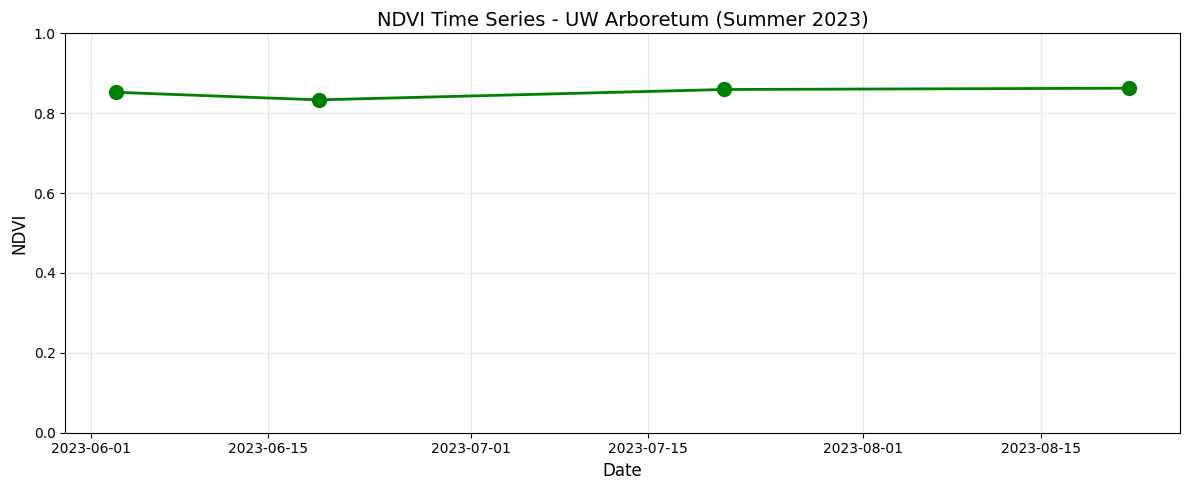

In [ ]:
# Plot the time series
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(df['date'], df['NDVI'], 'go-', markersize=10, linewidth=2)

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('NDVI', fontsize=12)
ax.set_title('NDVI Time Series - UW Arboretum (Summer 2023)', fontsize=14)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

---
## 7. Exporting Data

You can export processed data to Google Drive for further analysis in other software.

In [ ]:
# Export an image to Google Drive
#
# This creates a background task that runs on Google's servers.
# The file will appear in your Google Drive when complete.

export_task = ee.batch.Export.image.toDrive(
    image=median_composite.select(['SR_B4', 'SR_B3', 'SR_B2', 'NDVI']),
    description='Dane_County_Summer_2023',
    folder='GEE_Exports',           # Folder in your Drive
    region=dane_geom,
    scale=30,                        # Resolution in meters
    crs='EPSG:4326',                # Coordinate reference system
    maxPixels=1e9
)

# Uncomment to start the export:
# export_task.start()
# print("Export started! Check Google Drive in a few minutes.")

print("Export task configured (uncomment .start() to run)")

Export task configured (uncomment .start() to run)


In [ ]:
# Export a table (FeatureCollection) to Drive as CSV

export_table = ee.batch.Export.table.toDrive(
    collection=county_ndvi,
    description='WI_County_NDVI_Stats',
    folder='GEE_Exports',
    fileFormat='CSV'
)

# Uncomment to start:
# export_table.start()

print("Table export configured")

Table export configured


---
## Summary

### Key Concepts

| Concept | Description |
|---------|-------------|
| **Spectral signature** | Each surface type reflects light differently at different wavelengths |
| **NDVI** | (NIR - Red) / (NIR + Red); measures vegetation greenness |
| **Server-side vs client-side** | `ee.` objects are processed on Google's servers |
| **Lazy evaluation** | Computations only run when you request results |
| **Masking** | Setting unwanted pixels to transparent |
| **Compositing** | Combining multiple images into one |

### GEE Data Types

| Type | Use For |
|------|--------|
| `ee.Geometry` | Defining locations and regions |
| `ee.Feature` | A geometry with properties |
| `ee.FeatureCollection` | Multiple features (like a shapefile) |
| `ee.Image` | A single raster image |
| `ee.ImageCollection` | Multiple images (time series) |

### Common Operations

| Task | Code |
|------|------|
| Filter by date | `.filterDate('start', 'end')` |
| Filter by location | `.filterBounds(geometry)` |
| Filter by property | `.filter(ee.Filter.lt('prop', value))` |
| Apply function to all | `.map(function)` |
| Create composite | `.median()`, `.mean()`, `.max()` |
| Calculate index | `.normalizedDifference(['B1', 'B2'])` |
| Regional statistics | `.reduceRegion(reducer, geometry, scale)` |
| Zonal statistics | `.reduceRegions(collection, reducer, scale)` |